# Оптимальный размер блока при кодировании Хаффмана

**Автор:** Дмитрий Багацкий  
**Дисциплина:** Теория информации  
**Раздел курса:** первая часть, лекции 1–5  
**Формат:** самостоятельная исследовательская работа

## Аннотация
Код Хаффмана оптимален среди двоичных префиксных кодов, но целочисленность длин оставляет избыточность менее одного бита на кодируемый объект. В работе проверяется, насколько объединение независимых символов в блоки длины $m=1,\ldots,4$ уменьшает эту избыточность в расчёте на символ. Точные вероятности позволяют отделить собственно эффект блокирования от статистической ошибки оценивания. Выигрыш сопоставляется с экспоненциальным ростом блочного алфавита $M^m$. Для практического выбора предложен критерий: брать наименьший блок, уступающий лучшему исследованному результату не более $\varepsilon=0.01$ бит/символ. Все таблицы, графики и выводы формируются выполнением кода с фиксированными параметрами.

## 1. Постановка, цель и исследовательские вопросы

Пусть дискретный источник независимо порождает символы алфавита $\mathcal A=\{a_1,\ldots,a_M\}$ с точно известным распределением $P=(p_1,\ldots,p_M)$. Требуется сравнить посимвольный код Хаффмана и коды блоков длины $m=2,3,4$.

**Цель:** установить, как быстро средняя длина на символ приближается к энтропии и когда дальнейшее увеличение блока даёт слишком малый выигрыш относительно роста $M^m$.

1. Насколько блокирование уменьшает избыточность?
2. Какие распределения выигрывают сильнее?
3. Всегда ли переход $m\to m+1$ улучшает среднюю длину?
4. Насколько быстро $\ell_m$ приближается к энтропии?
5. Когда увеличение блока перестаёт быть практически значимым?
6. Как выигрыш соотносится с ростом $M^m$?
7. Как $m_\varepsilon^*$ зависит от формы распределения?

## 2. Теоретические сведения

Энтропия источника
$$H(X)=-\sum_{i=1}^M p_i\log_2p_i$$
есть среднее количество информации на символ и нижняя граница средней длины двоичного префиксного кода. Если длины слов равны $l_i$, то
$$\overline L=\sum_i p_i l_i,\qquad R=\overline L-H(X),\qquad R_{rel}=\frac{\overline L-H(X)}{H(X)}.$$
Последнее отношение не определено при $H=0$, что отдельно обрабатывается в коде.

Для невырожденного источника код Хаффмана удовлетворяет
$$H(X)\le \overline L<H(X)+1.$$
Нижняя граница связана с неравенством Крафта и невозможностью в среднем превзойти энтропию префиксным кодом. Верхняя означает, что округление идеальных длин $-\log_2p_i$ обходится менее чем в один бит на кодируемый объект.

Для IID-блока $X^m=(X_1,\ldots,X_m)$
$$P(x_1,\ldots,x_m)=\prod_{j=1}^mP(x_j),\qquad H(X^m)=mH(X).$$
Если $\overline L_m$ — длина кода целого блока, то
$$\ell_m=\frac{\overline L_m}{m},\qquad H(X)\le\ell_m<H(X)+\frac1m,$$
$$0\le R_m=\ell_m-H(X)<\frac1m.$$
Блок делит возможную ошибку целочисленного округления на $m$, но число объектов растёт как $|\mathcal A^m|=M^m$. Поэтому небольшой выигрыш может не оправдать построение и хранение значительно большей таблицы. При этом граница $1/m$ уменьшается монотонно, а фактическая $\ell_m$ — не обязательно.

In [1]:
import math, heapq, itertools, time
from dataclasses import dataclass
from typing import Hashable, Iterable, Mapping, Sequence
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

SEED=42
rng=np.random.default_rng(SEED)
TOL=1e-11
sns.set_theme(style="whitegrid",palette="colorblind")
pd.set_option("display.max_columns",20)
pd.set_option("display.float_format",lambda x:f"{x:.5f}")

## 3. Самостоятельная реализация алгоритма Хаффмана

Уникальный счётчик в элементах `heapq` разрешает совпадения весов и не допускает сравнения произвольных символов. Нулевые вероятности допустимы при заранее известном алфавите; в основных экспериментах все вероятности положительны.

In [2]:
@dataclass
class Node:
    """Узел двоичного дерева Хаффмана."""
    symbol: Hashable|None=None
    left: "Node|None"=None
    right: "Node|None"=None

def validate_distribution(probabilities: Sequence[float]) -> np.ndarray:
    """Проверяет распределение и возвращает массив float."""
    p=np.asarray(probabilities,dtype=float)
    if p.ndim!=1 or p.size==0 or np.any(~np.isfinite(p)) or np.any(p<0):
        raise ValueError("Вероятности должны быть конечными и неотрицательными")
    if not np.isclose(p.sum(),1.0): raise ValueError("Сумма вероятностей должна быть равна 1")
    return p

def entropy(probabilities: Sequence[float]) -> float:
    """Вычисляет энтропию Шеннона в битах."""
    p=validate_distribution(probabilities); positive=p[p>0]
    return float(-np.sum(positive*np.log2(positive)))

def build_huffman_code(weights: Mapping[Hashable,float]) -> dict[Hashable,str]:
    """Строит двоичный код Хаффмана через очередь с приоритетами."""
    if not weights: raise ValueError("Алфавит пуст")
    heap=[]; counter=itertools.count()
    for symbol,weight in weights.items():
        if not math.isfinite(weight) or weight<0: raise ValueError("Некорректный вес")
        heapq.heappush(heap,(float(weight),next(counter),Node(symbol=symbol)))
    if len(heap)==1: return {heap[0][2].symbol:"0"}
    while len(heap)>1:
        w1,_,left=heapq.heappop(heap);w2,_,right=heapq.heappop(heap)
        heapq.heappush(heap,(w1+w2,next(counter),Node(left=left,right=right)))
    root=heap[0][2];codebook={}
    def walk(node:Node,prefix:str)->None:
        if node.left is None and node.right is None: codebook[node.symbol]=prefix;return
        walk(node.left,prefix+"0");walk(node.right,prefix+"1")
    walk(root,"");return codebook

def code_lengths(codebook: Mapping[Hashable,str]) -> dict[Hashable,int]:
    """Возвращает длины кодовых слов."""
    return {symbol:len(word) for symbol,word in codebook.items()}

def average_length(probabilities: Mapping[Hashable,float],lengths: Mapping[Hashable,int])->float:
    """Вычисляет среднюю длину кода."""
    return float(sum(probabilities[s]*lengths[s] for s in probabilities))

def is_prefix_free(codebook: Mapping[Hashable,str])->bool:
    """Проверяет префиксность кодовой таблицы."""
    words=list(codebook.values())
    return len(words)==len(set(words)) and all(not b.startswith(a) for i,a in enumerate(words) for j,b in enumerate(words) if i!=j)

def kraft_sum(lengths: Mapping[Hashable,int])->float:
    """Вычисляет сумму Крафта."""
    return float(sum(2.0**(-length) for length in lengths.values()))

def block_distribution(probabilities: Sequence[float],m:int)->dict[tuple[int,...],float]:
    """Строит точное распределение IID-блоков длины m."""
    p=validate_distribution(probabilities)
    if not isinstance(m,int) or m<1: raise ValueError("m должно быть положительным целым")
    return {block:math.prod(p[i] for i in block) for block in itertools.product(range(len(p)),repeat=m)}

def block_metrics(probabilities: Sequence[float],m:int)->dict[str,float]:
    """Вычисляет характеристики точного блочного кода."""
    p=validate_distribution(probabilities);blocks=block_distribution(p,m);cb=build_huffman_code(blocks);lengths=code_lengths(cb)
    H=entropy(p);H_block=entropy(list(blocks.values()));L_block=average_length(blocks,lengths);ell=L_block/m;R=ell-H
    return {"M":len(p),"m":m,"blocks":len(blocks),"H":H,"H_block":H_block,"L_block":L_block,"ell":ell,"R":R,
            "R_rel":R/H if H>0 else np.nan,"kraft":kraft_sum(lengths),"bound":1/m}

def choose_block_size(results:pd.DataFrame,epsilon:float=.01)->int:
    """Выбирает минимальный m в epsilon от лучшей найденной длины."""
    best=results["ell"].min()
    return int(results.loc[results.ell<=best+epsilon+TOL,"m"].min())

## 4. Численная проверка теоретических соотношений

На распределении $P=(0.4,0.3,0.2,0.1)$ проверяются только свойства, непосредственно используемые в теории: префиксность, неравенство Крафта, аддитивность энтропии блока и границы Хаффмана.

In [3]:
p_check=np.array([.4,.3,.2,.1])
cb_check=build_huffman_code(dict(enumerate(p_check)))
lengths_check=code_lengths(cb_check)
assert is_prefix_free(cb_check)
assert kraft_sum(lengths_check)<=1+TOL

for m in range(1,5):
    blocks=block_distribution(p_check,m)
    metrics=block_metrics(p_check,m)
    assert abs(sum(blocks.values())-1)<1e-10
    assert abs(metrics["H_block"]-m*metrics["H"])<1e-9
    assert metrics["H_block"]-TOL<=metrics["L_block"]<metrics["H_block"]+1
    assert -TOL<=metrics["R"]<1/m+TOL

print("Проверены префиксность, сумма Крафта, H(X^m)=mH(X) и границы Хаффмана для m=1,…,4.")

Проверены префиксность, сумма Крафта, H(X^m)=mH(X) и границы Хаффмана для m=1,…,4.


## 5. Фиксированные распределения

Пять примеров представляют равномерный, точно согласованный с двоичными длинами, умеренно и сильно неравномерный источники, а также пятисимвольное распределение учебной задачи.

In [4]:
fixed={"P1 равномерное":np.array([.25,.25,.25,.25]),"P2 двоично-рациональное":np.array([.5,.25,.125,.125]),"P3 умеренно неравномерное":np.array([.4,.3,.2,.1]),"P4 сильно неравномерное":np.array([.7,.1,.1,.1]),"P5 учебная задача":np.array([.25,.25,.2,.15,.15])}
rows=[];start=time.perf_counter()
for name,p in fixed.items():
    source=[]
    for m in range(1,5):source.append({"distribution":name,**block_metrics(p,m)})
    ell1=source[0]["ell"]
    for r in source:
        r["gain"]=ell1-r["ell"];r["gain_percent"]=100*(ell1-r["ell"])/ell1
    rows.extend(source)
fixed_results=pd.DataFrame(rows);fixed_runtime=time.perf_counter()-start
fixed_summary=fixed_results.pivot(index="distribution",columns="m",values="R")
fixed_summary.columns=[f"R (m={m})" for m in fixed_summary.columns]
fixed_summary.insert(0,"H",fixed_results.groupby("distribution").H.first())
fixed_summary["Выигрыш, бит/символ"]=fixed_results.groupby("distribution").gain.max()
display(fixed_summary.round(5))
print(f"Расчёт фиксированных распределений: {fixed_runtime:.3f} с")

,H,R (m=1),R (m=2),R (m=3),R (m=4),"Выигрыш, бит/символ"
distribution,,,,,,
P1 равномерное,2.00000,0.00000,0.00000,0.00000,0.00000,0.00000
P2 двоично-рациональное,1.75000,0.00000,0.00000,0.00000,0.00000,0.00000
P3 умеренно неравномерное,1.84644,0.05356,0.01856,0.01256,0.00679,0.04677
P4 сильно неравномерное,1.35678,0.14322,0.00822,0.01855,0.00712,0.13610
P5 учебная задача,2.28548,0.01452,0.01202,0.00944,0.00744,0.00708


Расчёт фиксированных распределений: 0.026 с


Фактическая избыточность зависит от соответствия вероятностей целочисленным глубинам дерева. Уменьшающаяся граница $1/m$ не гарантирует строгого улучшения на каждом соседнем шаге.

При переходе от $m=1$ к $m=4$ алфавит растёт с 4 до 256 элементов, а для учебного пятисимвольного примера — с 5 до 625. Это показатель сложности, но не точная оценка памяти или времени.

## 6. Параметрическое двоичное семейство

Рассматривается $P(p)=(p,1-p)$ на 100 точках $p\in[0.5,0.99]$. При $m=1$ двоичный Хаффман всегда тратит один бит, поэтому блокирование особенно интересно вдали от $p=0.5$.

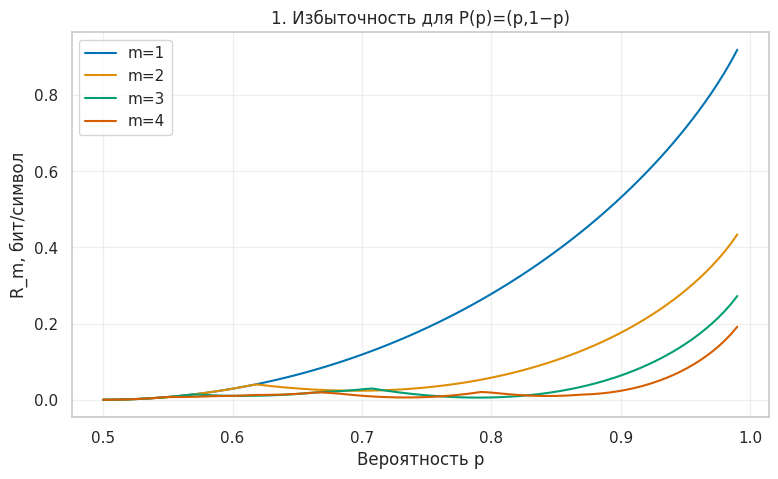

In [5]:
binary_rows=[]
for p in np.linspace(.5,.99,100):
    local=[]
    for m in range(1,5):local.append({"parameter":p,**block_metrics([p,1-p],m)})
    ell1=local[0]["ell"]
    for r in local:r["gain"]=ell1-r["ell"]
    binary_rows.extend(local)
binary=pd.DataFrame(binary_rows)

# 1. R_m(p)
plt.figure(figsize=(9,5))
for m,d in binary.groupby("m"):plt.plot(d.parameter,d.R,label=f"m={m}")
plt.xlabel("Вероятность p");plt.ylabel("R_m, бит/символ");plt.title("1. Избыточность для P(p)=(p,1−p)");plt.legend();plt.grid(alpha=.3);plt.show()

На графике показано расстояние от средней длины до энтропии: $R_m(p)=\ell_m(p)-H(p)$. При $p=0.5$ источник равномерный и $R_m=0$ для всех блоков. Для $m=1$ код всегда тратит один бит, поэтому $R_1(p)=1-H(p)$ растёт вместе с концентрацией источника. Блокирование обычно снижает избыточность, но изломы и пересечения кривых возникают при дискретной перестройке дерева Хаффмана. Поэтому $m+1$ не обязан быть лучше $m$ при каждом конкретном $p$.

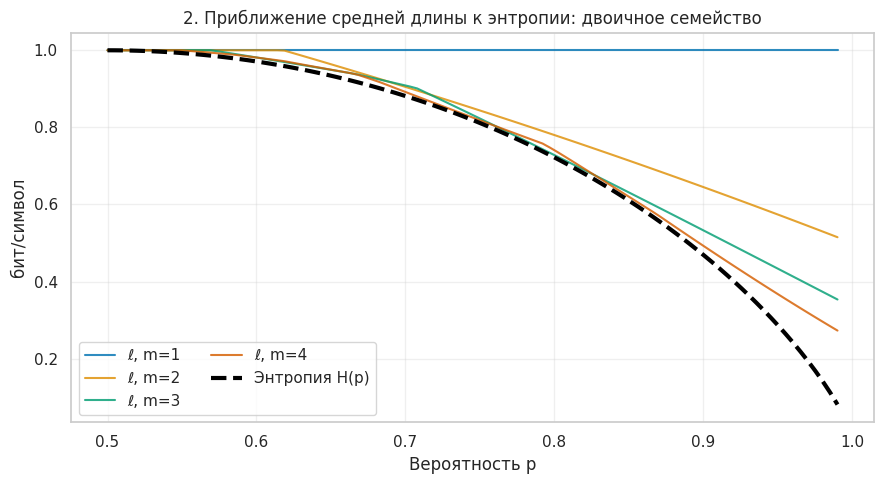

In [6]:
# 2. ell_m(p) и H(p)
plt.figure(figsize=(9,5))
for m,d in binary.groupby("m"):
    plt.plot(d.parameter,d.ell,label=f"ℓ, m={m}",alpha=.82)
base=binary[binary.m==1]
plt.plot(base.parameter,base.H,color="black",linestyle="--",linewidth=3,zorder=10,label="Энтропия H(p)")
plt.xlabel("Вероятность p");plt.ylabel("бит/символ")
plt.title("2. Приближение средней длины к энтропии: двоичное семейство")
plt.legend(ncol=2);plt.grid(alpha=.3);plt.tight_layout();plt.show()

Чёрная пунктирная линия — энтропия $H(p)$. Вертикальное расстояние от неё до кривой $\ell_m(p)$ равно избыточности $R_m(p)$. При росте $p$ энтропия уменьшается, тогда как посимвольный код остаётся на уровне $\ell_1=1$ бит/символ. Блочные коды лучше следуют за энтропией, особенно для концентрированного источника.

## 7. Четырёхсимвольное семейство

Для $P_a=(a,(1-a)/3,(1-a)/3,(1-a)/3)$ берётся 100 точек $a\in[0.25,0.95]$. Семейство плавно переходит от равномерного источника к источнику с доминирующим символом.

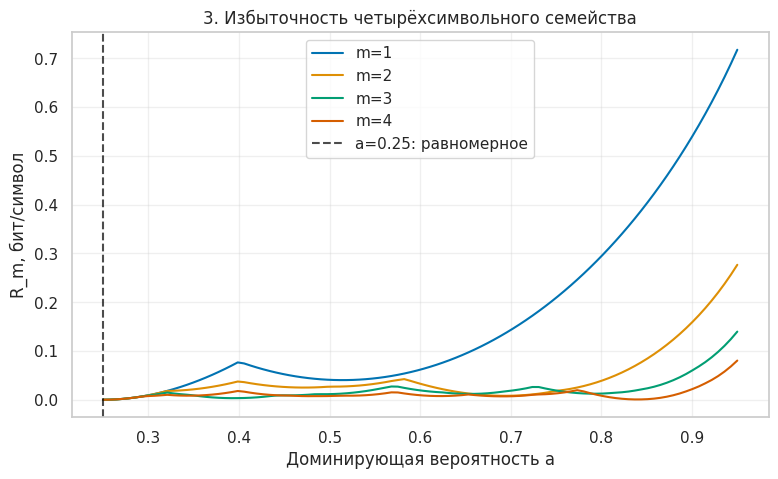

In [7]:
family_rows=[]
for a in np.linspace(.25,.95,100):
    p=np.r_[a,np.repeat((1-a)/3,3)];local=[]
    for m in range(1,5):local.append({"parameter":a,**block_metrics(p,m)})
    ell1=local[0]["ell"]
    for r in local:r["gain"]=ell1-r["ell"]
    family_rows.extend(local)
family=pd.DataFrame(family_rows)

# 3. R_m(a)
plt.figure(figsize=(9,5))
for m,d in family.groupby("m"):plt.plot(d.parameter,d.R,label=f"m={m}")
plt.axvline(.25,color="black",linestyle="--",alpha=.7,label="a=0.25: равномерное")
plt.xlabel("Доминирующая вероятность a");plt.ylabel("R_m, бит/символ");plt.title("3. Избыточность четырёхсимвольного семейства");plt.legend();plt.grid(alpha=.3);plt.show()

При $a=0.25$ распределение равномерное, двухбитный код точен и $R_m=0$. С ростом $a$ источник концентрируется, но избыточность изменяется немонотонно: изломы соответствуют перестройкам дерева Хаффмана. Большие блоки обычно уменьшают $R_m$, однако пересечения кривых снова показывают, что следующий размер блока не гарантирует улучшения в каждой точке.

## 8. Практический выбор размера блока

Пусть $\ell_{min}=\min_{1\le k\le4}\ell_k$. Предлагается выбирать
$$m_\varepsilon^*=\min\{m:\ell_m\le\ell_{min}+\varepsilon\}.$$
Это не глобальный оптимум практической системы, а способ выбрать наименьшую сложность среди исследованных $m=1,\ldots,4$. Основное значение $\varepsilon=0.01$ бит/символ; чувствительность проверяется для 0.005 и 0.02.

In [8]:
def selection_table(data:pd.DataFrame,group_col:str,epsilons=(.005,.01,.02))->pd.DataFrame:
    rows=[]
    for value,d in data.groupby(group_col,sort=True):
        row={group_col:value,"best_m":int(d.loc[d.ell.idxmin(),"m"]),"ell_min":d.ell.min()}
        for eps in epsilons:row[f"m_eps_{eps}"]=choose_block_size(d,eps)
        rows.append(row)
    return pd.DataFrame(rows)

fixed_choice=selection_table(fixed_results,"distribution")
summary=[]
for name,d in fixed_results.groupby("distribution"):
    msel=int(fixed_choice.loc[fixed_choice.distribution==name,"m_eps_0.01"].iloc[0]);chosen=d[d.m==msel].iloc[0];first=d[d.m==1].iloc[0]
    summary.append([name,int(d.loc[d.ell.idxmin(),"m"]),msel,first.ell,chosen.ell,first.ell-chosen.ell,int(chosen.blocks)])
summary=pd.DataFrame(summary,columns=["распределение","лучший m","m*_eps","ell_1","ell_выбранное","выигрыш","число блоков"])
display(summary.round(5));display(fixed_choice)

binary_choice=selection_table(binary,"parameter");family_choice=selection_table(family,"parameter")
sens=pd.DataFrame({"семейство":["двоичное","четырёхсимвольное"],**{f"среднее m*, eps={e}":[binary_choice[f"m_eps_{e}"].mean(),family_choice[f"m_eps_{e}"].mean()] for e in [.005,.01,.02]}})
display(Markdown("**Чувствительность к ε:**"));display(sens.round(3))

,распределение,лучший m,m*_eps,ell_1,ell_выбранное,выигрыш,число блоков
0,P1 равномерное,1,1,2.00000,2.00000,0.00000,4
1,P2 двоично-рациональное,1,1,1.75000,1.75000,0.00000,4
2,P3 умеренно неравномерное,4,3,1.90000,1.85900,0.04100,64
3,P4 сильно неравномерное,4,2,1.50000,1.36500,0.13500,16
4,P5 учебная задача,4,1,2.30000,2.30000,0.00000,5


,distribution,best_m,ell_min,m_eps_0.005,m_eps_0.01,m_eps_0.02
0,P1 равномерное,1,2.00000,1,1,1
1,P2 двоично-рациональное,1,1.75000,1,1,1
2,P3 умеренно неравномерное,4,1.85323,4,3,2
3,P4 сильно неравномерное,4,1.36390,2,2,2
4,P5 учебная задача,4,2.29292,2,1,1


**Чувствительность к ε:**

,семейство,"среднее m*, eps=0.005","среднее m*, eps=0.01","среднее m*, eps=0.02"
0,двоичное,3.19000,2.98000,2.66000
1,четырёхсимвольное,3.06000,2.85000,2.47000


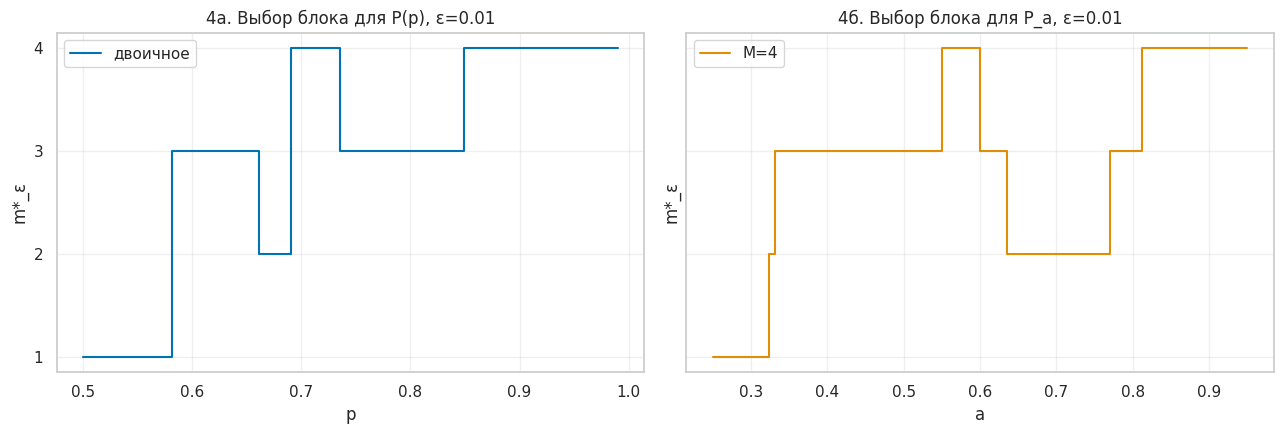

In [9]:
# 4. Выбранный m* вдоль параметрических семейств
fig,axes=plt.subplots(1,2,figsize=(13,4.5),sharey=True)
axes[0].step(binary_choice.parameter,binary_choice["m_eps_0.01"],where="mid",label="двоичное")
axes[1].step(family_choice.parameter,family_choice["m_eps_0.01"],where="mid",color="C1",label="M=4")
axes[0].set(title="4а. Выбор блока для P(p), ε=0.01",xlabel="p",ylabel="m*_ε")
axes[1].set(title="4б. Выбор блока для P_a, ε=0.01",xlabel="a",ylabel="m*_ε")
for ax in axes:ax.set_yticks([1,2,3,4]);ax.legend();ax.grid(alpha=.3)
plt.tight_layout();plt.show()

Для каждой точки сначала находится $\ell_{min}$, затем выбирается наименьший $m$, уступающий ему не более $\varepsilon=0.01$ бит/символ. Значение 1 означает, что усложнение даёт практически незначимый выигрыш; значение 4 — что только максимальный исследованный блок укладывается в допуск. Ступени возникают из-за дискретного выбора, а немонотонность — из-за перестроек дерева. Выбранный $m_\varepsilon^*$ не обязательно даёт абсолютный минимум: он предпочитает меньший алфавит при почти одинаковой длине.

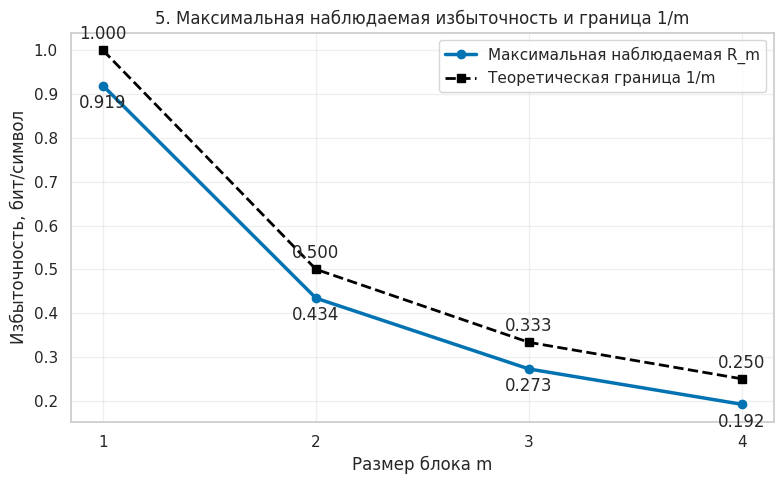

,m,max_R,mean_R,bound
0,1,0.91921,0.21363,1.00000
1,2,0.43416,0.06696,0.50000
2,3,0.27254,0.03042,0.33333
3,4,0.19190,0.01818,0.25000


In [10]:
# 5. Проверка верхней границы
all_results=pd.concat([fixed_results.assign(experiment="фиксированные"),binary.assign(experiment="двоичное"),family.assign(experiment="M=4")],ignore_index=True)
bound_check=all_results.groupby("m",as_index=False).agg(max_R=("R","max"),mean_R=("R","mean"),bound=("bound","first"))
x=bound_check.m.to_numpy(); observed=bound_check.max_R.to_numpy(); theory=bound_check.bound.to_numpy()
plt.figure(figsize=(8,5))
plt.plot(x,observed,marker="o",linewidth=2.5,label="Максимальная наблюдаемая R_m")
plt.plot(x,theory,marker="s",color="black",linestyle="--",linewidth=2,label="Теоретическая граница 1/m")
for m,y in zip(x,observed):plt.annotate(f"{y:.3f}",(m,y),xytext=(0,-16),textcoords="offset points",ha="center")
for m,y in zip(x,theory):plt.annotate(f"{y:.3f}",(m,y),xytext=(0,8),textcoords="offset points",ha="center")
plt.xticks([1,2,3,4]);plt.xlabel("Размер блока m");plt.ylabel("Избыточность, бит/символ")
plt.title("5. Максимальная наблюдаемая избыточность и граница 1/m")
plt.legend();plt.grid(alpha=.3);plt.tight_layout();plt.show();display(bound_check.round(5))

Для каждого $m$ берётся максимум $R_m$ по всем фиксированным и параметрическим распределениям. Сплошная линия должна оставаться ниже пунктирной $1/m$. Это численная проверка на исследованной сетке, а не доказательство теоремы, причём распределение, дающее максимум, может различаться для разных $m$.

## 9. Обсуждение результатов и ограничения

Блокирование полезно не само по себе, а когда посимвольные целочисленные длины плохо согласованы с вероятностями. Если вероятности уже равны степеням $1/2$ в подходящем дереве, $L=H$ и улучшать нечего. В остальных случаях блок создаёт более тонкую сетку вероятностей и распределяет ошибку округления между несколькими символами.

Цена улучшения в этой работе характеризуется числом $M^m$. Это лишь показатель роста сложности, а не точная оценка памяти или времени: конкретная реализация таблицы может использовать сжатое или каноническое представление.

Ограничения: символы считаются независимыми и одинаково распределёнными; используется только двоичный Хаффман; исследуются $m=1,\ldots,4$; не моделируются ошибки передачи и адаптивное обновление; не учитывается конкретный формат хранения дерева; критерий $m_\varepsilon^*$ зависит от $\varepsilon$ и конечного набора блоков. Результаты описывают ожидаемую длину, а размер конкретного файла дополнительно зависит от длины сообщения и служебных данных.

## 10. Итоговые выводы

Ответы ниже формируются из фактически рассчитанных таблиц и последовательно соответствуют семи исследовательским вопросам.

In [11]:
def count_nonmonotone(data:pd.DataFrame,group_col:str)->int:
    return sum(np.any(np.diff(d.sort_values("m").ell)>TOL) for _,d in data.groupby(group_col))

fixed_gains=fixed_results.groupby("distribution").gain.max().sort_values(ascending=False)
binary_nonmono=count_nonmonotone(binary,"parameter")
family_nonmono=count_nonmonotone(family,"parameter")
largest_family_gain=float(max(binary.gain.max(),family.gain.max()))
fixed_r=fixed_results.pivot(index="distribution",columns="m",values="R")
selected_counts=pd.concat([binary_choice["m_eps_0.01"],family_choice["m_eps_0.01"]]).value_counts().sort_index()

conclusion=f"""1. **Величина уменьшения избыточности.** Для фиксированных источников $R_1$ лежит от
{fixed_r[1].min():.4f} до {fixed_r[1].max():.4f} бит/символ, а при $m=4$ — от {fixed_r[4].min():.4f}
до {fixed_r[4].max():.4f}. Максимальный выигрыш среди фиксированных примеров равен {fixed_gains.iloc[0]:.4f} бит/символ.

2. **Где выигрыш больше.** В фиксированном наборе лидирует «{fixed_gains.index[0]}». Равномерный и
двоично-рациональный источники не выигрывают, поскольку уже имеют $L=H$. Следовательно, решающей является исходная
целочисленная избыточность, а не одна лишь степень неравномерности.

3. **Монотонность.** Ухудшение хотя бы на одном шаге $m\\to m+1$ обнаружено для {binary_nonmono} из 100 точек
двоичного семейства и {family_nonmono} из 100 точек четырёхсимвольного. Теорема гарантирует уменьшение верхней
границы $1/m$, но не монотонность фактической $\\ell_m$.

4. **Скорость приближения.** Максимальная наблюдаемая избыточность по всем сериям изменилась от
{bound_check.loc[bound_check.m==1,"max_R"].iloc[0]:.4f} при $m=1$ до
{bound_check.loc[bound_check.m==4,"max_R"].iloc[0]:.4f} бит/символ при $m=4$; во всех случаях $R_m<1/m$.

5. **Практически достаточный блок.** При $\\varepsilon=0.01$ среди 200 точек параметрических семейств частоты
выбора равны: """+", ".join(f"m={int(m)}: {int(n)}" for m,n in selected_counts.items())+f""". Увеличивать блок дальше
выбранного нет смысла по принятому критерию: дополнительное улучшение меньше 0.01 бит/символ.

6. **Выигрыш и сложность.** Наибольший выигрыш в параметрических сериях равен {largest_family_gain:.4f} бит/символ,
тогда как для $M=4$ число блоков возрастает с 4 до 256. Поэтому большой блок разумен только при заметном снижении
длины и допустимой сложности таблицы.

7. **Зависимость выбора от формы.** График 4 показывает ступенчатое и местами немонотонное изменение
$m_\\varepsilon^*$: форма распределения влияет через перестройки дерева, а чувствительность к $\\varepsilon$
приведена в отдельной таблице.

Итак, блоковый Хаффман действительно приближает среднюю длину к энтропии, но лучший найденный $m=4$ не всегда
является разумным выбором. Критерий $m_\\varepsilon^*$ делает компромисс явным: он сохраняет почти всю найденную
экономию и предпочитает меньший блочный алфавит. Теоретические границы подтверждены во всех вычисленных случаях."""
display(Markdown(conclusion))

1. **Величина уменьшения избыточности.** Для фиксированных источников $R_1$ лежит от
0.0000 до 0.1432 бит/символ, а при $m=4$ — от 0.0000
до 0.0074. Максимальный выигрыш среди фиксированных примеров равен 0.1361 бит/символ.

2. **Где выигрыш больше.** В фиксированном наборе лидирует «P4 сильно неравномерное». Равномерный и
двоично-рациональный источники не выигрывают, поскольку уже имеют $L=H$. Следовательно, решающей является исходная
целочисленная избыточность, а не одна лишь степень неравномерности.

3. **Монотонность.** Ухудшение хотя бы на одном шаге $m\to m+1$ обнаружено для 33 из 100 точек
двоичного семейства и 30 из 100 точек четырёхсимвольного. Теорема гарантирует уменьшение верхней
границы $1/m$, но не монотонность фактической $\ell_m$.

4. **Скорость приближения.** Максимальная наблюдаемая избыточность по всем сериям изменилась от
0.9192 при $m=1$ до
0.1919 бит/символ при $m=4$; во всех случаях $R_m<1/m$.

5. **Практически достаточный блок.** При $\varepsilon=0.01$ среди 200 точек параметрических семейств частоты
выбора равны: m=1: 28, m=2: 26, m=3: 81, m=4: 65. Увеличивать блок дальше
выбранного нет смысла по принятому критерию: дополнительное улучшение меньше 0.01 бит/символ.

6. **Выигрыш и сложность.** Наибольший выигрыш в параметрических сериях равен 0.7273 бит/символ,
тогда как для $M=4$ число блоков возрастает с 4 до 256. Поэтому большой блок разумен только при заметном снижении
длины и допустимой сложности таблицы.

7. **Зависимость выбора от формы.** График 4 показывает ступенчатое и местами немонотонное изменение
$m_\varepsilon^*$: форма распределения влияет через перестройки дерева, а чувствительность к $\varepsilon$
приведена в отдельной таблице.

Итак, блоковый Хаффман действительно приближает среднюю длину к энтропии, но лучший найденный $m=4$ не всегда
является разумным выбором. Критерий $m_\varepsilon^*$ делает компромисс явным: он сохраняет почти всю найденную
экономию и предпочитает меньший блочный алфавит. Теоретические границы подтверждены во всех вычисленных случаях.